[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter18_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 18: Systemic Risk and Networks

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and table of Lecture 18 on real daily data for 13 banks.

**Abbreviations.** VaR: Value-at-Risk (the loss exceeded with probability α); ES: Expected Shortfall (average loss beyond VaR); MES: Marginal Expected Shortfall (average bank loss on the market's worst 5% of days); LRMES: long-run MES (bank loss in a market crisis); SRISK: capital shortfall of a bank in a crisis; CoVaR: VaR of the system when a bank is in distress; ΔCoVaR: CoVaR with the bank in distress minus CoVaR with the bank at its median; VAR: vector autoregression; FEVD: forecast error variance decomposition; OLS: ordinary least squares; BIC: Bayesian information criterion; GACV: generalized approximate cross-validation; FRM: Financial Risk Meter; GJR-GARCH: GARCH model with a leverage term (Glosten, Jagannathan & Runkle); GARCH: generalized autoregressive conditional heteroskedasticity; DCC: dynamic conditional correlation; VIX: CBOE volatility index of the S&P 500; BET: main index of the Bucharest Stock Exchange; i.i.d.: independent and identically distributed.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_18'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.linear_model import QuantileRegressor, ElasticNetCV
from scipy import optimize
try:
    from arch import arch_model
except ImportError:                      # Colab: the arch package is not preinstalled
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])
    from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Course colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#1F2A44'   # reference lines, bands and grid only
REGION_COL = {'US': MainBlue, 'EU': IDAred, 'RO': Forest}
REGION_LAB = {'US': 'US banks', 'EU': 'European banks', 'RO': 'Romanian banks (BVB)'}
EVENTS = [('2011-08-08', 'Euro crisis'), ('2016-06-24', 'Brexit vote'), ('2018-12-19', 'RO bank tax'),
          ('2020-03-16', 'COVID-19'), ('2023-03-13', 'SVB'), ('2025-04-07', 'Tariffs')]

HERE = '.'
SEED = 42
B_BOOT = 999
RESULTS = {}


def save_fig(name):
    """Save the figure as transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [jsonable(v) for v in x]
    if isinstance(x, np.ndarray):
        return [jsonable(v) for v in x.tolist()]
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    if isinstance(x, pd.Timestamp):
        return str(x.date())
    return x


def mark_events(ax, ymax=None):
    """Vertical reference lines for events, with black labels."""
    for d, lab in EVENTS:
        t = pd.Timestamp(d)
        if ax.get_xlim()[0] <= mdates.date2num(t) <= ax.get_xlim()[1]:
            ax.axvline(t, color=Gray, lw=0.5, ls=':')
            ax.text(t, ax.get_ylim()[1] if ymax is None else ymax, lab, rotation=90, fontsize=6.5, color='black',
                    ha='right', va='top')


import tempfile
# with SAVE_TO_DRIVE = True (Colab cell above) tables and charts are kept in OUT_DIR; otherwise in a temporary folder
KEEP = bool(globals().get('SAVE_TO_DRIVE', False))
HERE = globals().get('OUT_DIR', '.') if KEEP else tempfile.gettempdir()


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE = True also save it as PDF and PNG in OUT_DIR."""
    if KEEP:
        for ext in ('pdf', 'png'):
            plt.savefig(os.path.join(HERE, f'{name}.{ext}'), bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

## Data

- Daily prices, January 2010 – 18 September 2026: six US banks, five European banks, Banca Transilvania and BRD; S&P 500, Euro Stoxx 50, BET, VIX.
- Prices aligned on common trading days first, then daily log returns in %; volatility: daily Parkinson estimator (from the daily high–low range).
- Romanian banks: days without trades removed.

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
START = '2010-01-01'
END = '2026-09-18'

# bank -> (symbol, name, region)
BANKS = {
    'JPM':  ('JPM.US',    'JPMorgan Chase',       'US'),
    'BAC':  ('BAC.US',    'Bank of America',      'US'),
    'C':    ('C.US',      'Citigroup',            'US'),
    'GS':   ('GS.US',     'Goldman Sachs',        'US'),
    'MS':   ('MS.US',     'Morgan Stanley',       'US'),
    'WFC':  ('WFC.US',    'Wells Fargo',          'US'),
    'DBK':  ('DBK.XETRA', 'Deutsche Bank',        'EU'),
    'BNP':  ('BNP.PA',    'BNP Paribas',          'EU'),
    'SAN':  ('SAN.MC',    'Santander',            'EU'),
    'INGA': ('INGA.AS',   'ING',                  'EU'),
    'HSBA': ('HSBA.LSE',  'HSBC',                 'EU'),
    'TLV':  ('TLV.RO',    'Banca Transilvania',   'RO'),
    'BRD':  ('BRD.RO',    'BRD-Groupe SG',        'RO'),
}
US = [k for k, v in BANKS.items() if v[2] == 'US']
EU = [k for k, v in BANKS.items() if v[2] == 'EU']
RO = [k for k, v in BANKS.items() if v[2] == 'RO']
ALL = US + EU + RO
NAMES = {k: v[1] for k, v in BANKS.items()}
INDICES = {'SPX': ('GSPC.INDX', 'S&P 500'), 'SX5E': ('STOXX50E.INDX', 'Euro Stoxx 50'),
           'BET': ('BET', 'BET'), 'VIX': ('VIX.INDX', 'VIX')}
REGION_INDEX = {'US': 'SPX', 'EU': 'SX5E', 'RO': 'BET'}


def read_market(symbol):
    """Read the daily price series of one symbol from the course data."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def bank_frame(key, start=START, end=END):
    """Daily prices and volume of one bank, with the adjusted price and the corrections above."""
    symbol, _, region = BANKS[key]
    d = read_market(symbol).loc[start:end].copy()
    d = d[(d.index.dayofweek < 5) & (d['adjusted_close'] > 0)]
    if region == 'RO':
        d = d[d['volume'] > 0]                                   # days without trades
    if key == 'TLV' and pd.Timestamp('2016-05-30') in d.index:
        # bonus-share adjustment: the post-ex-date factor also applies on 30 May 2016
        f = d.loc['2016-05-31', 'adjusted_close'] / d.loc['2016-05-31', 'close']
        d.loc['2016-05-30', 'adjusted_close'] = d.loc['2016-05-30', 'close'] * f
    return d


def bank_price(key, start=START, end=END):
    return bank_frame(key, start, end)['adjusted_close'].rename(key)


def index_close(key, start=START, end=END):
    s = read_market(INDICES[key][0])['close'].loc[start:end]
    s = s[(s.index.dayofweek < 5) & (s > 0)].dropna()
    if key != 'VIX':
        s = s[s.diff() != 0]                                     # holidays filled with the previous price
    return s.rename(key)


def prices(keys, start=START, end=END):
    """Daily prices of banks and/or indices, on common trading days only."""
    cols = [bank_price(k, start, end) if k in BANKS else index_close(k, start, end) for k in keys]
    return pd.concat(cols, axis=1, join='inner').dropna()


def joint_returns(keys, start=START, end=END):
    """Daily log returns in %: prices are aligned on common trading days first, then returns are computed."""
    return 100 * np.log(prices(keys, start, end)).diff().dropna()


def bank_range_vol(keys, start=START, end=END):
    """Daily Parkinson volatility (in %, annualised), on the days common to all banks."""
    out = []
    for k in keys:
        d = bank_frame(k, start, end)
        rng = np.log(d['high'] / d['low']).where(d['high'] > d['low'])
        s2 = rng ** 2 / (4 * np.log(2))
        floor = s2.where(s2 > 0).cummin().ffill()                  # smallest positive value observed UP TO day t
        s2 = s2.fillna(floor)                                     # days with high = low: no look-ahead bias
        out.append((100 * np.sqrt(252 * s2)).rename(k))
    return pd.concat(out, axis=1, join='inner').dropna()


def system_return(R, members):
    """System return: equal-weighted portfolio of the banks (log returns in %, daily approximation)."""
    return R[members].mean(axis=1)


# daily log returns in % (common days) and log Parkinson volatility
R = joint_returns(ALL + ['SPX', 'SX5E', 'BET', 'VIX'])
V = np.log(bank_range_vol(ALL))
print(R.index[0].date(), '->', R.index[-1].date(), len(R), 'common days')


def system_ex(k, members):
    """Return of the regional system without bank k (equal-weighted portfolio)."""
    return R[[j for j in members if j != k]].mean(axis=1)


def region_of(k):
    return BANKS[k][2]

2010-01-05 -> 2026-09-18 3960 common days


## Systemic risk measures

- Functions for the exposure measures: MES, LRMES, SRISK and the break-even leverage.
- CoVaR and ΔCoVaR by quantile regression (static and with state variables), with a moving-block bootstrap.
- Diebold–Yilmaz connectedness: VAR estimation, generalized FEVD, the spillover table and the rolling total index.
- Financial Risk Meter: L1-penalized quantile regression with the penalty chosen by GACV.

In [4]:
def mes(r_i, r_m, alpha=0.05):
    """MES (%): average loss of the bank on the days when the market is in its alpha-probability tail."""
    q = np.quantile(r_m, alpha)
    return -np.mean(np.asarray(r_i)[np.asarray(r_m) <= q])


def mes_threshold(r_i, r_m, c=-2.0):
    """MES (%) on the days when the market falls by more than |c|% (the definition used for LRMES)."""
    return -np.mean(np.asarray(r_i)[np.asarray(r_m) < c])


def lrmes(mes2_pct):
    """Long-run loss in a crisis (market -40% over six months): LRMES = 1 - exp(-18 MES), MES as a fraction."""
    return 1 - np.exp(-18 * mes2_pct / 100)


def srisk_ratio(lrm, leverage, k=0.08):
    """SRISK / market equity W: k(L - 1) - (1 - k)(1 - LRMES), with L = (D + W)/W."""
    return k * (leverage - 1) - (1 - k) * (1 - lrm)


def breakeven_leverage(lrm, k=0.08):
    """Leverage L* above which SRISK > 0: L* = 1 + (1 - k)(1 - LRMES)/k."""
    return 1 + (1 - k) * (1 - lrm) / k


def qreg(y, X, q):
    """Quantile regression (Koenker-Bassett); returns the coefficients [intercept, slopes]."""
    return QuantReg(np.asarray(y), sm.add_constant(np.asarray(X), has_constant='add')).fit(q=q, max_iter=5000).params


def covar_static(x_sys, x_i, alpha=0.01):
    """Unconditional CoVaR and Delta-CoVaR (%, positive = losses).

    Quantile regression at level alpha: X_sys = a + b X_i;
    CoVaR_alpha = -(a + b q_alpha(X_i)); Delta-CoVaR = b (q_50(X_i) - q_alpha(X_i))."""
    x_sys, x_i = np.asarray(x_sys), np.asarray(x_i)
    a, b = qreg(x_sys, x_i, alpha)
    qa, qm = np.quantile(x_i, alpha), np.quantile(x_i, 0.5)
    return {'a': a, 'b': b, 'var_i': -qa, 'covar': -(a + b * qa), 'covar_med': -(a + b * qm),
            'dcovar': b * (qm - qa), 'var_sys': -np.quantile(x_sys, alpha)}


def block_bootstrap_idx(n, block=20, rng=None):
    """Indices for the moving-block bootstrap (Künsch), fixed-length blocks."""
    rng = rng or np.random.default_rng(0)
    starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
    return (starts[:, None] + np.arange(block)[None, :]).ravel()[:n]


def covar_boot(x_sys, x_i, alpha=0.01, B=200, block=20, seed=0):
    """95% percentile interval for Delta-CoVaR by moving-block bootstrap."""
    x_sys, x_i = np.asarray(x_sys), np.asarray(x_i)
    rng = np.random.default_rng(seed)
    d = []
    for _ in range(B):
        idx = block_bootstrap_idx(len(x_i), block, rng)
        d.append(covar_static(x_sys[idx], x_i[idx], alpha)['dcovar'])
    return np.percentile(d, [2.5, 97.5])


def covar_dynamic(x_sys, x_i, M, alpha=0.01):
    """Time-varying Delta-CoVaR with state variables M_{t-1} (Adrian & Brunnermeier, 2016).

    X_i,t = a + c'M_{t-1} at levels alpha and 50%  ->  VaR_i,t;
    X_sys,t = a + b X_i,t + c'M_{t-1} at level alpha  ->  Delta-CoVaR_t = b (q50_i,t - qalpha_i,t)."""
    ci_a = qreg(x_i, M, alpha)
    ci_m = qreg(x_i, M, 0.5)
    cs = qreg(x_sys, np.column_stack([x_i, M]), alpha)
    Mc = sm.add_constant(np.asarray(M), has_constant='add')
    qa, qm = Mc @ ci_a, Mc @ ci_m
    return pd.DataFrame({'var_i': -qa, 'dcovar': cs[1] * (qm - qa)}, index=getattr(x_i, 'index', None)), cs[1]


def var_fit(Y, p):
    """VAR(p) estimated by OLS; returns the coefficients A_1..A_p (k x k) and the residual covariance matrix."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    X = np.hstack([np.ones((T - p, 1))] + [Y[p - l - 1:T - l - 1] for l in range(p)])
    Yt = Y[p:]
    B = np.linalg.lstsq(X, Yt, rcond=None)[0]
    E = Yt - X @ B
    S = E.T @ E / (len(Yt) - X.shape[1])
    A = [B[1 + l * k:1 + (l + 1) * k].T for l in range(p)]
    return A, S


def var_bic(Y, pmax=5):
    """VAR order chosen by the Bayesian information criterion (BIC, Schwarz), with the maximum-likelihood residual covariance matrix."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    best = None
    n = T - pmax
    for p in range(1, pmax + 1):
        A, S = var_fit(Y[pmax - p:], p)
        S_ml = S * (n - 1 - p * k) / n                        # maximum-likelihood covariance E'E / n
        bic = np.log(np.linalg.det(S_ml)) + np.log(n) * p * k * k / n
        if best is None or bic < best[1]:
            best = (p, bic)
    return best[0]


def ma_coefs(A, H):
    """Moving-average coefficients Phi_0..Phi_{H-1}."""
    k = A[0].shape[0]
    Phi = [np.eye(k)]
    for h in range(1, H):
        Phi.append(sum(A[l] @ Phi[h - l - 1] for l in range(min(h, len(A)))))
    return Phi


def gfevd(A, S, H=10):
    """Generalized forecast error variance decomposition (Pesaran-Shin), rows normalised."""
    Phi = ma_coefs(A, H)
    k = S.shape[0]
    num = np.zeros((k, k))
    den = np.zeros(k)
    for P in Phi:
        PS = P @ S
        num += PS ** 2
        den += np.diag(P @ S @ P.T)
    theta = num / np.diag(S)[None, :] / den[:, None]
    return theta / theta.sum(axis=1, keepdims=True)


def spillover_table(theta, names):
    """Connectedness table: contributions (%), FROM, TO, NET and the total index."""
    k = theta.shape[0]
    D = 100 * theta
    off = D - np.diag(np.diag(D))
    frm, to = off.sum(axis=1), off.sum(axis=0)
    tab = pd.DataFrame(D, index=names, columns=names)
    return {'table': tab, 'from': pd.Series(frm, index=names), 'to': pd.Series(to, index=names),
            'net': pd.Series(to - frm, index=names), 'total': off.sum() / k,
            'pairwise_net': pd.DataFrame(off.T - off, index=names, columns=names)}


def rolling_total(Y, window=250, step=5, p=2, H=10):
    """Total connectedness index on rolling windows."""
    Y = pd.DataFrame(Y)
    out, frm_to = {}, {}
    for end in range(window, len(Y) + 1, step):
        w = Y.iloc[end - window:end]
        A, S = var_fit(w.values, p)
        st = spillover_table(gfevd(A, S, H), list(Y.columns))
        out[Y.index[end - 1]] = st['total']
        frm_to[Y.index[end - 1]] = st['net']
    return pd.Series(out), pd.DataFrame(frm_to).T


def check_loss(u, tau):
    return u * (tau - (u < 0))


def lasso_qr_gacv(y, X, tau=0.05, lambdas=None):
    """L1-penalized quantile regression; lambda chosen by the generalized approximate cross-validation criterion GACV = sum rho_tau(res) / (n - df)."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    n = len(y)
    lambdas = np.logspace(-4, -0.5, 15) if lambdas is None else lambdas
    rows = []
    for lam in lambdas:
        m = QuantileRegressor(quantile=tau, alpha=lam, solver='highs').fit(X, y)
        res = y - m.predict(X)
        df = int(np.sum(np.abs(m.coef_) > 1e-8))
        g = check_loss(res, tau).sum() / max(n - df, 1)
        rows.append((lam, g, df, m.coef_.copy()))
    i = int(np.argmin([r[1] for r in rows]))
    return {'lambda': rows[i][0], 'gacv': [r[1] for r in rows], 'df': [r[2] for r in rows],
            'lambdas': list(lambdas), 'coef': rows[i][3], 'df_sel': rows[i][2]}

In [5]:
MACRO = ['SPX', 'SX5E', 'VIX']
LAMBDAS = np.logspace(-6, -1.5, 20)
EPISODES = [('GFC: Lehman', '2008-09-01', '2008-11-30'), ('Euro crisis', '2011-07-01', '2011-10-31'), ('Brexit vote', '2016-06-20', '2016-07-15'), ('RO bank tax', '2018-12-10', '2019-01-31'), ('COVID-19', '2020-02-15', '2020-04-30'), ('SVB / Credit Suisse', '2023-03-01', '2023-04-15'), ('Tariff shock', '2025-03-25', '2025-04-30')]
INTL = US + EU

## 1. Three banking systems

- Equal-weighted bank portfolios of each region, rebalanced daily.

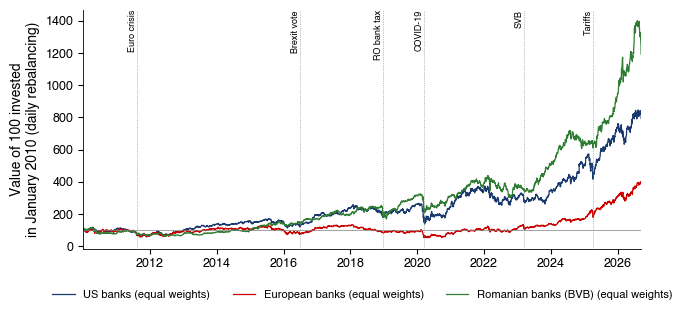

{'US': {'last': np.float64(791.4396458018049),
  'maxdd': -0.5134495497313767,
  'maxdd_date': Timestamp('2011-11-23 00:00:00'),
  'vol': np.float64(29.00594688646466),
  'peak_date': Timestamp('2026-08-14 00:00:00')},
 'EU': {'last': np.float64(383.9986901630275),
  'maxdd': -0.6074757993626247,
  'maxdd_date': Timestamp('2020-04-21 00:00:00'),
  'vol': np.float64(30.233310080260484),
  'peak_date': Timestamp('2026-09-08 00:00:00')},
 'RO': {'last': np.float64(1232.709040423833),
  'maxdd': -0.4682701412380772,
  'maxdd_date': Timestamp('2012-06-06 00:00:00'),
  'vol': np.float64(23.33081568342561),
  'peak_date': Timestamp('2026-08-04 00:00:00')}}

In [6]:
def fig_bank_indices():
    """Equal-weighted bank portfolios (US, Europe, Romania), base 100 at the start of 2010."""
    fig, ax = plt.subplots(figsize=(7.2, 3.1))
    out = {}
    for reg, mem in [('US', US), ('EU', EU), ('RO', RO)]:
        s = 100 * (1 + (np.exp(R[mem] / 100) - 1).mean(axis=1)).cumprod()     # daily rebalancing
        ax.plot(s.index, s.values, color=REGION_COL[reg], lw=0.9, label=f'{REGION_LAB[reg]} (equal weights)')
        dd = s / s.cummax() - 1
        out[reg] = {'last': s.iloc[-1], 'maxdd': dd.min(), 'maxdd_date': dd.idxmin(),
                    'vol': R[mem].mean(axis=1).std() * np.sqrt(252), 'peak_date': s.idxmax()}
    ax.axhline(100, color=Gray, lw=0.5)
    ax.set_ylabel('Value of 100 invested\nin January 2010 (daily rebalancing)')
    ax.set_xlim(R.index[0], R.index[-1])
    mark_events(ax)
    legend_outside_bottom(ax, ncol=3, y=-0.13)
    save_fig('ch18_bank_indices')
    return out


fig_bank_indices()

## 2. MES, LRMES and the break-even leverage

- MES 5% against the market index of each region, with a moving-block bootstrap.
- LRMES = 1 − exp(−18 × MES at the −2% threshold); break-even leverage L* = 1 + (1 − k)(1 − LRMES)/k, k = 8%.

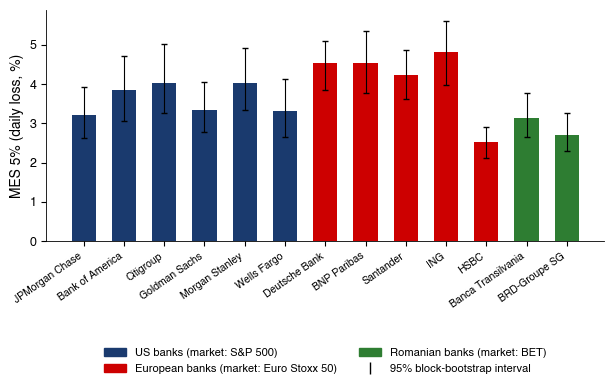

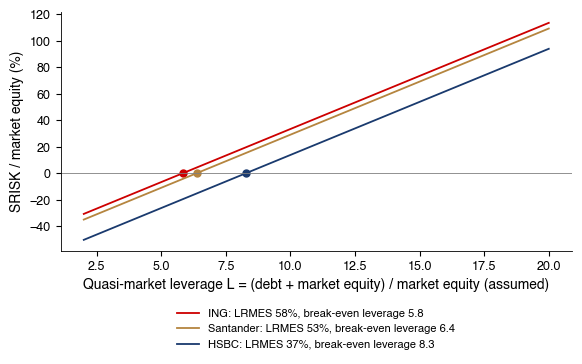

,mes5,lo,hi,mes2,n2,lrmes,Lstar,Lstar55,beta,es5_m,var1
JPM,3.219,2.632,3.928,3.613,138.0,0.478,7.002,9.967,1.154,2.721,4.829
BAC,3.846,3.070,4.705,4.382,138.0,0.546,6.226,8.808,1.326,2.721,5.988
C,4.030,3.259,5.009,4.580,138.0,0.561,6.043,8.534,1.420,2.721,5.868
GS,3.345,2.781,4.057,3.781,138.0,0.494,6.823,9.700,1.222,2.721,4.806
MS,4.039,3.347,4.922,4.616,138.0,0.564,6.010,8.485,1.444,2.721,5.827
WFC,3.320,2.649,4.127,3.786,138.0,0.494,6.817,9.691,1.178,2.721,5.780
DBK,4.540,3.850,5.088,4.547,196.0,0.559,6.073,8.579,1.385,3.163,7.189
BNP,4.534,3.771,5.342,4.541,196.0,0.558,6.079,8.588,1.392,3.163,6.182
SAN,4.230,3.611,4.865,4.236,196.0,0.533,6.365,9.016,1.371,3.163,5.828
INGA,4.805,3.977,5.608,4.820,196.0,0.580,5.829,8.216,1.442,3.163,7.163


In [7]:
def mes_table():
    """MES 5% (against the regional index), MES at the -2% threshold and LRMES, with a block-bootstrap interval."""
    rows = {}
    rng = np.random.default_rng(SEED)
    for k in ALL:
        m = R[REGION_INDEX[region_of(k)]].values
        x = R[k].values
        boot = []
        for _ in range(B_BOOT):
            idx = block_bootstrap_idx(len(x), 20, rng)
            boot.append(mes(x[idx], m[idx], 0.05))
        m2 = mes_threshold(x, m, -2.0)
        rows[k] = {'mes5': mes(x, m, 0.05), 'lo': np.percentile(boot, 2.5), 'hi': np.percentile(boot, 97.5),
                   'mes2': m2, 'n2': int((m < -2).sum()), 'lrmes': lrmes(m2), 'Lstar': breakeven_leverage(lrmes(m2)),
                   'Lstar55': breakeven_leverage(lrmes(m2), 0.055),
                   'beta': np.cov(x, m)[0, 1] / np.var(m, ddof=1), 'es5_m': -m[m <= np.quantile(m, 0.05)].mean(),
                   'var1': -np.quantile(x, 0.01)}
    return pd.DataFrame(rows).T


def fig_mes(t):
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    xs = np.arange(len(ALL))
    cols = [REGION_COL[region_of(k)] for k in ALL]
    ax.bar(xs, t['mes5'], color=cols, width=0.6)
    ax.errorbar(xs, t['mes5'], yerr=[t['mes5'] - t['lo'], t['hi'] - t['mes5']], fmt='none', ecolor='black',
                capsize=2, lw=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels([NAMES[k] for k in ALL], rotation=35, ha='right', fontsize=7.5)
    ax.set_ylabel('MES 5% (daily loss, %)')
    h = [plt.Rectangle((0, 0), 1, 1, color=REGION_COL[r]) for r in ['US', 'EU', 'RO']]
    lab = ['US banks (market: S&P 500)', 'European banks (market: Euro Stoxx 50)', 'Romanian banks (market: BET)']
    h.append(plt.Line2D([], [], color='black', marker='|', ls='', ms=8))
    lab.append('95% block-bootstrap interval')
    ax.legend(h, lab, loc='upper center', bbox_to_anchor=(0.5, -0.42), ncol=2, frameon=False)
    save_fig('ch18_mes')


def fig_srisk(t):
    """SRISK / market equity as a function of leverage, for the banks with the largest, median and smallest LRMES."""
    order = t['lrmes'].sort_values()
    pick = [order.index[-1], order.index[len(order) // 2], order.index[0]]
    L = np.linspace(2, 20, 200)
    fig, ax = plt.subplots(figsize=(6.6, 3.1))
    for k, c in zip(pick, [IDAred, Amber, MainBlue]):
        lr = t.loc[k, 'lrmes']
        ax.plot(L, 100 * srisk_ratio(lr, L), color=c, lw=1.3,
                label=f'{NAMES[k]}: LRMES {100 * lr:.0f}%, break-even leverage {t.loc[k, "Lstar"]:.1f}')
        ax.plot(t.loc[k, 'Lstar'], 0, 'o', color=c, ms=5)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xlabel('Quasi-market leverage L = (debt + market equity) / market equity (assumed)')
    ax.set_ylabel('SRISK / market equity (%)')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch18_srisk')
    return pick


mt = mes_table()
fig_mes(mt)
fig_srisk(mt)
mt.round(3)

## 3. CoVaR and ΔCoVaR

- System of bank i: equal-weighted portfolio of the other banks of the same region.
- Quantile regression at 1%; 95% intervals from a moving-block bootstrap (blocks of 20 days).

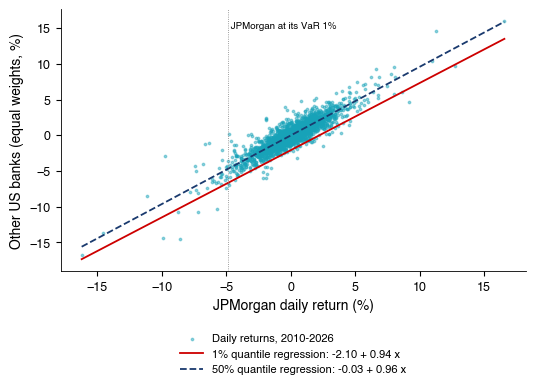

{0.01: (np.float64(-2.095957955340793), np.float64(0.9417207295768243)), 0.5: (np.float64(-0.027366245471438552), np.float64(0.9616821358131036))}


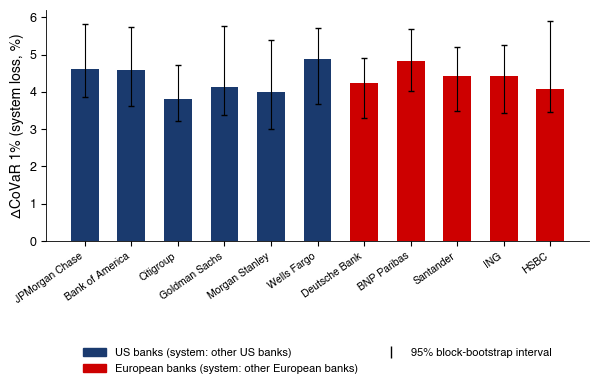

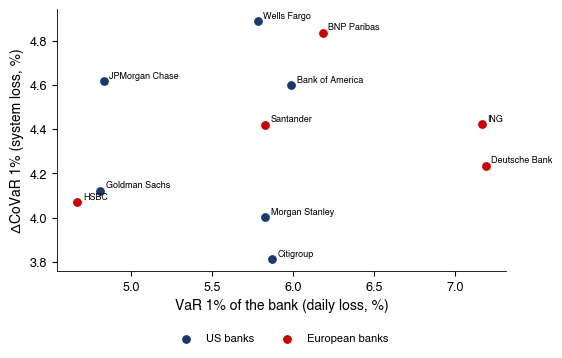

Spearman VaR vs ΔCoVaR: 0.16
Spearman 1% vs 5% rankings: 0.1


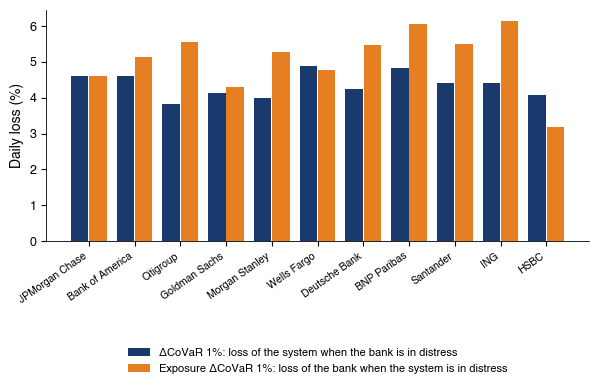

,a,b,var_i,covar,covar_med,dcovar,var_sys,lo,hi,exp_covar,exp_dcovar,exp_b
JPM,-2.10,0.94,4.83,6.64,2.03,4.62,5.07,3.86,5.81,6.77,4.61,0.90
BAC,-2.10,0.76,5.99,6.65,2.05,4.60,4.72,3.61,5.75,7.81,5.13,1.07
C,-2.35,0.64,5.87,6.13,2.32,3.81,4.82,3.23,4.74,8.23,5.55,1.13
GS,-2.52,0.85,4.81,6.59,2.46,4.12,5.05,3.38,5.78,6.86,4.29,0.84
MS,-2.60,0.68,5.83,6.56,2.55,4.00,4.98,2.99,5.39,7.91,5.29,1.05
WFC,-3.09,0.84,5.78,7.94,3.05,4.89,5.00,3.68,5.71,7.73,4.77,0.94
DBK,-2.97,0.59,7.19,7.19,2.96,4.24,5.15,3.31,4.92,9.49,5.48,1.05
BNP,-2.57,0.77,6.18,7.34,2.51,4.84,5.22,4.02,5.70,9.10,6.07,1.15
SAN,-3.02,0.75,5.83,7.40,2.98,4.42,5.39,3.48,5.21,8.87,5.49,1.01
INGA,-2.81,0.61,7.16,7.19,2.77,4.42,5.24,3.44,5.26,9.78,6.14,1.16


In [8]:
def fig_covar_qr():
    """Quantile regression of the system on JPMorgan: the 1% and 50% lines."""
    xs, xi = system_ex('JPM', US), R['JPM']
    fig, ax = plt.subplots(figsize=(6.0, 3.4))
    ax.scatter(xi, xs, s=3, color=Teal, alpha=0.45, label='Daily returns, 2010-2026')
    grid = np.linspace(xi.min(), xi.max(), 50)
    out = {}
    for q, c, ls in [(0.01, IDAred, '-'), (0.5, MainBlue, '--')]:
        a, b = qreg(xs, xi, q)
        ax.plot(grid, a + b * grid, color=c, ls=ls, lw=1.3, label=f'{q:.0%} quantile regression: {a:.2f} + {b:.2f} x')
        out[q] = (a, b)
    qa = np.quantile(xi, 0.01)
    ax.axvline(qa, color=Gray, lw=0.6, ls=':')
    ax.text(qa, xs.max(), ' JPMorgan at its VaR 1%', fontsize=7, color='black', va='top')
    ax.set_xlabel('JPMorgan daily return (%)')
    ax.set_ylabel('Other US banks (equal weights, %)')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch18_covar_qr')
    return out


def covar_table(alpha):
    """CoVaR and Delta-CoVaR for the US and European banks (system = the other banks of the region)."""
    rows = {}
    for i, k in enumerate(US + EU):
        mem = US if k in US else EU
        xs = system_ex(k, mem)
        c = covar_static(xs, R[k], alpha)
        lo, hi = covar_boot(xs, R[k], alpha, B=B_BOOT, block=20, seed=SEED + i)
        e = covar_static(R[k], xs, alpha)                      # exposure: the bank given a crisis of the system
        rows[k] = {**c, 'lo': lo, 'hi': hi, 'exp_covar': e['covar'], 'exp_dcovar': e['dcovar'], 'exp_b': e['b']}
    return pd.DataFrame(rows).T


def fig_dcovar(t):
    ks = list(t.index)
    xs = np.arange(len(ks))
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    ax.bar(xs, t['dcovar'], color=[REGION_COL[region_of(k)] for k in ks], width=0.6)
    ax.errorbar(xs, t['dcovar'], yerr=[t['dcovar'] - t['lo'], t['hi'] - t['dcovar']], fmt='none', ecolor='black',
                capsize=2, lw=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels([NAMES[k] for k in ks], rotation=35, ha='right', fontsize=7.5)
    ax.set_ylabel('ΔCoVaR 1% (system loss, %)')
    h = [plt.Rectangle((0, 0), 1, 1, color=REGION_COL[r]) for r in ['US', 'EU']] + \
        [plt.Line2D([], [], color='black', marker='|', ls='', ms=8)]
    ax.legend(h, ['US banks (system: other US banks)', 'European banks (system: other European banks)',
                  '95% block-bootstrap interval'], loc='upper center', bbox_to_anchor=(0.5, -0.42), ncol=2,
              frameon=False)
    save_fig('ch18_dcovar')


def fig_var_vs_dcovar(t):
    fig, ax = plt.subplots(figsize=(5.8, 3.4))
    for reg in ['US', 'EU']:
        s = t[[region_of(k) == reg for k in t.index]]
        ax.scatter(s['var_i'], s['dcovar'], s=28, color=REGION_COL[reg], label=REGION_LAB[reg], zorder=3)
        for k in s.index:
            ax.annotate(NAMES[k], (s.loc[k, 'var_i'], s.loc[k, 'dcovar']), xytext=(4, 2), textcoords='offset points',
                        fontsize=6.5, color='black')
    ax.set_xlabel('VaR 1% of the bank (daily loss, %)')
    ax.set_ylabel('ΔCoVaR 1% (system loss, %)')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch18_var_vs_dcovar')
    from scipy.stats import spearmanr
    return spearmanr(t['var_i'], t['dcovar']).correlation


def fig_exposure(t):
    ks = list(t.index)
    xs = np.arange(len(ks))
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    ax.bar(xs - 0.2, t['dcovar'], 0.38, color=MainBlue, label='ΔCoVaR 1%: loss of the system when the bank is in distress')
    ax.bar(xs + 0.2, t['exp_dcovar'], 0.38, color=Orange, label='Exposure ΔCoVaR 1%: loss of the bank when the system is in distress')
    ax.set_xticks(xs)
    ax.set_xticklabels([NAMES[k] for k in ks], rotation=35, ha='right', fontsize=7.5)
    ax.set_ylabel('Daily loss (%)')
    legend_outside_bottom(ax, ncol=1, y=-0.42)
    save_fig('ch18_exposure')


print(fig_covar_qr())
c1 = covar_table(0.01)
c5 = covar_table(0.05)
fig_dcovar(c1)
print('Spearman VaR vs ΔCoVaR:', round(fig_var_vs_dcovar(c1), 2))
print('Spearman 1% vs 5% rankings:', round(spearmanr(c1['dcovar'], c5['dcovar']).correlation, 2))
fig_exposure(c1)
c1.round(2)

## 4. ΔCoVaR over time

- State variables at t − 1: log VIX, regional index return, system return.

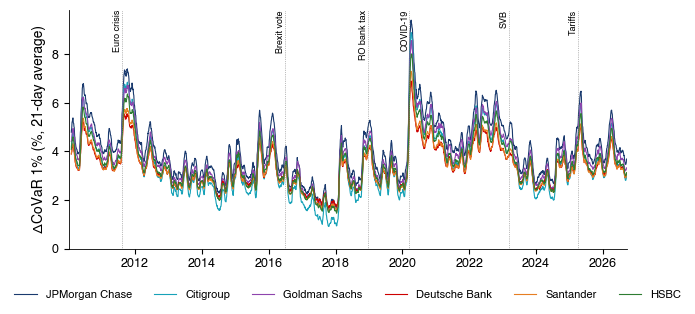

,JPM,C,GS,DBK,SAN,HSBA
mean,4.10,3.46,3.78,3.37,3.37,3.55
2017,2.16,1.43,1.98,2.04,1.93,1.89
March 2020,9.06,8.51,8.10,6.65,7.02,7.61


In [9]:
def dynamic_covar():
    """Time-varying Delta-CoVaR 1%; state: log VIX, regional index return and system return (t-1)."""
    out, betas = {}, {}
    for k in ['JPM', 'C', 'GS', 'DBK', 'SAN', 'HSBA']:
        mem = US if k in US else EU
        xs = system_ex(k, mem)
        Mv = pd.concat([np.log(index_close('VIX')).reindex(R.index).ffill(), R[REGION_INDEX[region_of(k)]], xs],
                       axis=1).shift(1)
        d = pd.concat([xs.rename('sys'), R[k].rename('x'), Mv], axis=1).dropna()
        f, b = covar_dynamic(d['sys'], d['x'], d.iloc[:, 2:].values, 0.01)
        f.index = d.index
        out[k], betas[k] = f, b
    return out, betas


def fig_dcovar_dynamic(dyn):
    fig, ax = plt.subplots(figsize=(7.2, 3.1))
    cols = {'JPM': MainBlue, 'C': Teal, 'GS': Purple, 'DBK': IDAred, 'SAN': Orange, 'HSBA': Forest}
    for k, f in dyn.items():
        s = f['dcovar'].rolling(21).mean()
        ax.plot(s.index, s.values, color=cols[k], lw=0.8, label=NAMES[k])
    ax.set_ylabel('ΔCoVaR 1% (%, 21-day average)')
    ax.set_xlim(R.index[0], R.index[-1])
    ax.set_ylim(bottom=0)
    mark_events(ax)
    legend_outside_bottom(ax, ncol=6, y=-0.13)
    save_fig('ch18_dcovar_dynamic')


dyn, betas = dynamic_covar()
fig_dcovar_dynamic(dyn)
pd.DataFrame({k: {'mean': f['dcovar'].mean(), '2017': f['dcovar'].loc['2017'].mean(), 'March 2020': f['dcovar'].loc['2020-03'].mean()} for k, f in dyn.items()}).round(2)

## 5. Diebold–Yilmaz connectedness

- VAR on the log Parkinson volatility of 13 banks, generalized variance decomposition at 10 days.

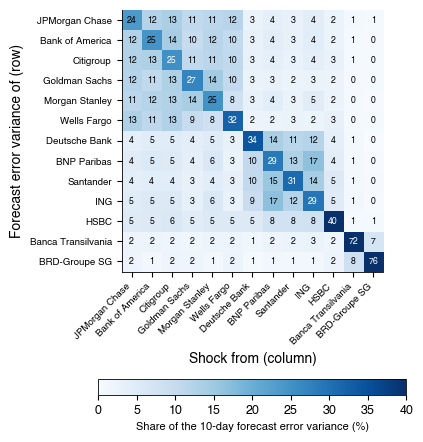

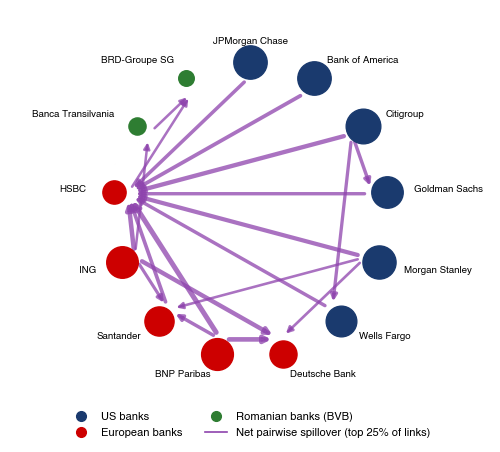

VAR order 2 | total connectedness 63.9 | on returns 75.4


,to,from,net
JPM,86.2,76.4,9.8
BAC,86.4,75.5,10.9
C,93.8,74.8,19.0
GS,75.4,73.0,2.4
MS,85.0,75.0,9.9
WFC,71.3,67.7,3.6
DBK,53.3,65.9,-12.6
BNP,77.3,71.3,6.0
SAN,63.5,68.9,-5.4
INGA,76.0,70.8,5.2


In [10]:
def spill_static(H=10):
    p = var_bic(V.values, 5)
    A, S = var_fit(V.values, p)
    st = spillover_table(gfevd(A, S, H), ALL)
    ret = R[ALL]
    pr = var_bic(ret.values, 5)
    Ar, Sr = var_fit(ret.values, pr)
    st_r = spillover_table(gfevd(Ar, Sr, H), ALL)
    return st, p, st_r, pr


def fig_spill_table(st):
    tab = st['table']
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    im = ax.imshow(tab.values, cmap='Blues', vmin=0, vmax=40)
    for i in range(len(ALL)):
        for j in range(len(ALL)):
            v = tab.values[i, j]
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=6.3, color='white' if v > 25 else 'black')
    ax.set_xticks(range(len(ALL)))
    ax.set_yticks(range(len(ALL)))
    ax.set_xticklabels([NAMES[k] for k in ALL], rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels([NAMES[k] for k in ALL], fontsize=7)
    ax.set_xlabel('Shock from (column)')
    ax.set_ylabel('Forecast error variance of (row)')
    cb = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.04, pad=0.28)
    cb.set_label('Share of the 10-day forecast error variance (%)', fontsize=8)
    save_fig('ch18_spill_table')


def fig_spill_network(st):
    """Network of net pairwise connectedness: arrow from transmitter to receiver, width ~ net effect."""
    pn = st['pairwise_net']                     # pn[i, j] > 0: i is a net transmitter to j
    n = len(ALL)
    ang = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, n, endpoint=False)
    pos = {k: (np.cos(a), np.sin(a)) for k, a in zip(ALL, ang)}
    thr = np.quantile(pn.values[pn.values > 0], 0.75)
    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    for i in ALL:
        for j in ALL:
            v = pn.loc[i, j]
            if v > thr:
                (x0, y0), (x1, y1) = pos[i], pos[j]
                ax.annotate('', xy=(x1 * 0.9, y1 * 0.9), xytext=(x0 * 0.9, y0 * 0.9),
                            arrowprops=dict(arrowstyle='-|>', color=Purple, lw=0.4 + 0.9 * v, alpha=0.75,
                                            shrinkA=6, shrinkB=6))
    to = st['to']
    for k in ALL:
        x, y = pos[k]
        ax.scatter(x, y, s=60 + 6 * to[k], color=REGION_COL[region_of(k)], zorder=3)
        ax.text(1.2 * x, 1.14 * y, NAMES[k], ha='left' if x > 0.2 else ('right' if x < -0.2 else 'center'),
                va='center', fontsize=7, color='black')
    ax.set_xlim(-1.75, 1.75)
    ax.set_ylim(-1.35, 1.35)
    ax.axis('off')
    h = [plt.Line2D([], [], marker='o', ls='', color=REGION_COL[r], ms=7) for r in ['US', 'EU', 'RO']]
    h.append(plt.Line2D([], [], color=Purple, lw=1.2))
    ax.legend(h, [REGION_LAB[r] for r in ['US', 'EU', 'RO']] + ['Net pairwise spillover (top 25% of links)'],
              loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False)
    save_fig('ch18_spill_network')
    return thr


st, p, st_r, pr = spill_static()
fig_spill_table(st)
fig_spill_network(st)
print('VAR order', p, '| total connectedness', round(st['total'], 1), '| on returns', round(st_r['total'], 1))
pd.DataFrame({'to': st['to'], 'from': st['from'], 'net': st['net']}).round(1)

## 6. Connectedness over time

- 250-day windows, every 5 days, VAR(2), H = 10.

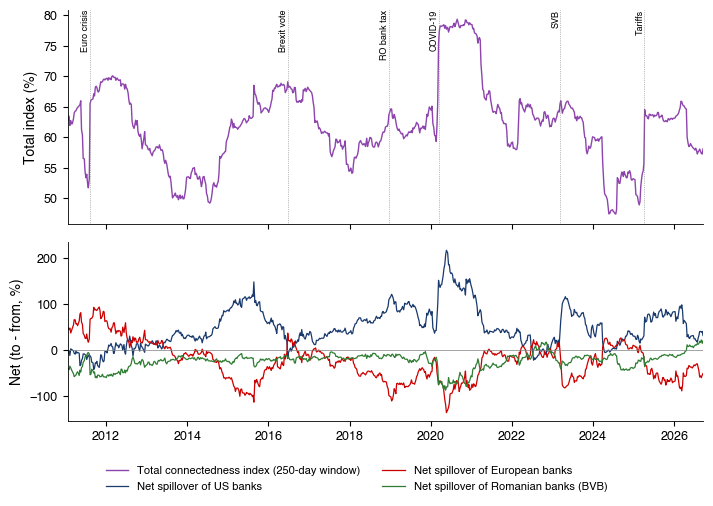

count    744.0
mean      62.0
std        6.6
min       47.4
25%       58.2
50%       62.4
75%       65.4
max       79.3
dtype: float64

In [11]:
def spill_rolling():
    tot, net = rolling_total(V, window=250, step=5, p=2, H=10)
    return tot, net


def fig_spill_rolling(tot, net):
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.6), sharex=True, gridspec_kw={'height_ratios': [1.2, 1]})
    axes[0].plot(tot.index, tot.values, color=Purple, lw=1.0, label='Total connectedness index (250-day window)')
    axes[0].set_ylabel('Total index (%)')
    axes[0].set_xlim(tot.index[0], tot.index[-1])
    mark_events(axes[0])
    for reg in ['US', 'EU', 'RO']:
        mem = [k for k in ALL if region_of(k) == reg]
        s = net[mem].sum(axis=1)
        axes[1].plot(s.index, s.values, color=REGION_COL[reg], lw=0.9, label=f'Net spillover of {REGION_LAB[reg]}')
    axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_ylabel('Net (to - from, %)')
    fig.tight_layout()
    h = axes[0].get_lines()[:1] + axes[1].get_lines()[:3]
    fig.legend(h, [l.get_label() for l in h], loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False)
    save_fig('ch18_spill_rolling')


tot, net = spill_rolling()
fig_spill_rolling(tot, net)
tot.describe().round(1)

## 7. Financial Risk Meter

- L1-penalized quantile regression at 5% on 63-day windows; penalty chosen by GACV.
- The rolling series takes a few minutes (390 windows × 13 banks).

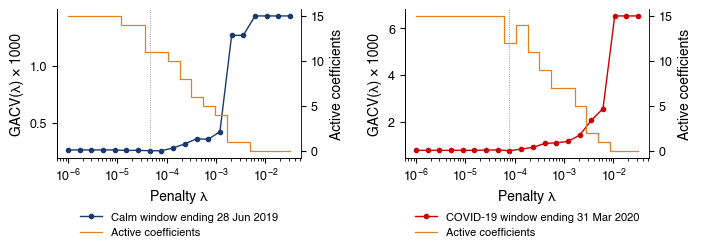

{'2019-06-28': {'lambda': np.float64(4.548777947003778e-05), 'df': 11, 'gacv_min': np.float64(0.0002539998997612978)}, '2020-03-31': {'lambda': np.float64(7.847599703514606e-05), 'df': 12, 'gacv_min': np.float64(0.0007708372919225498)}}


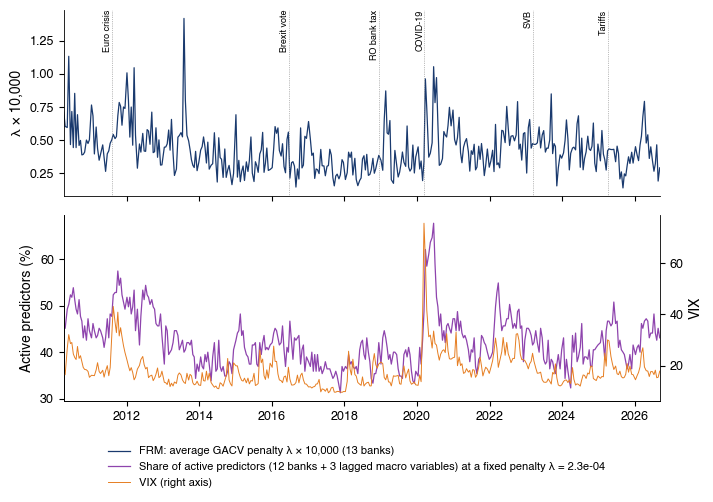

{'corr_frm_vix': np.float64(0.3488727381342896), 'corr_dens_vix': np.float64(0.6199655732817195), 'frm_mean': np.float64(4.318224717783507e-05), 'dens_mean': np.float64(0.4244444444444445), 'dens_max': 0.6769230769230768, 'dens_max_date': Timestamp('2020-06-17 00:00:00'), 'dens_min': 0.3128205128205129, 'dens_min_date': Timestamp('2017-11-21 00:00:00'), 'n_windows': 390}


In [12]:
def frm_design():
    """Daily returns (fractions) of the banks and the macro variables lagged by one day."""
    Rf = R / 100
    Mac = Rf[MACRO].shift(1).add_suffix('_lag')
    return Rf[ALL].join(Mac).dropna()


def frm_window(D, k, tau=0.05):
    X = D[[j for j in ALL if j != k] + [c for c in D.columns if c.endswith('_lag')]]
    return lasso_qr_gacv(D[k].values, X.values, tau, LAMBDAS)


def frm_series(window=63, step=10, lam_fixed=2e-4):
    """FRM = average lambda (GACV) across banks, on rolling 63-day windows; and the share of active predictors
    (12 banks + 3 lagged macro variables) at a fixed lambda."""
    D = frm_design()
    rows = {}
    cache = os.path.join(HERE, 'ch18_frm.csv')
    if os.environ.get('MFM_FRM_CACHE') and os.path.exists(cache):
        return pd.read_csv(cache, index_col=0, parse_dates=True), LAMBDAS[int(np.argmin(np.abs(LAMBDAS - lam_fixed)))]
    j_fix = int(np.argmin(np.abs(LAMBDAS - lam_fixed)))
    for end in range(window, len(D) + 1, step):
        w = D.iloc[end - window:end]
        lam, dens = [], []
        for k in ALL:
            r = frm_window(w, k)
            lam.append(r['lambda'])
            dens.append(r['df'][j_fix] / (len(ALL) - 1 + len(MACRO)))
        rows[D.index[end - 1]] = {'frm': np.mean(lam), 'density': np.mean(dens)}
    f = pd.DataFrame(rows).T
    f.to_csv(os.path.join(HERE, 'ch18_frm.csv'))
    return f, LAMBDAS[j_fix]


def fig_frm_gacv():
    """GACV curve for JPMorgan in a calm and in a crisis window."""
    D = frm_design()
    out = {}
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
    for ax, (end, lab, c) in zip(axes, [('2019-06-28', 'Calm window ending 28 Jun 2019', MainBlue),
                                        ('2020-03-31', 'COVID-19 window ending 31 Mar 2020', IDAred)]):
        w = D.loc[:end].iloc[-63:]
        r = frm_window(w, 'JPM')
        ax.plot(LAMBDAS, 1e3 * np.array(r['gacv']), 'o-', color=c, ms=3, lw=1, label=lab)
        ax.axvline(r['lambda'], color=Gray, lw=0.6, ls=':')
        ax.set_xscale('log')
        ax.set_xlabel('Penalty λ')
        ax.set_ylabel('GACV(λ) × 1000')
        ax2 = ax.twinx()
        ax2.step(LAMBDAS, r['df'], where='mid', color=Orange, lw=0.9, label='Active coefficients')
        ax2.set_ylabel('Active coefficients')
        ax2.spines['right'].set_visible(True)
        h = ax.get_lines()[:1] + ax2.get_lines()[:1]
        ax.legend(h, [l.get_label() for l in h], loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1, frameon=False)
        out[end] = {'lambda': r['lambda'], 'df': r['df_sel'], 'gacv_min': min(r['gacv'])}
    fig.tight_layout()
    save_fig('ch18_frm_gacv')
    return out


def fig_frm_rolling(f, lam_fix):
    vix = index_close('VIX').reindex(f.index)
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.4), sharex=True)
    axes[0].plot(f.index, 1e4 * f['frm'], color=MainBlue, lw=0.9, label='FRM: average GACV penalty λ × 10,000 (13 banks)')
    axes[0].set_ylabel('λ × 10,000')
    axes[1].plot(f.index, 100 * f['density'], color=Purple, lw=0.9,
                 label=f'Share of active predictors (12 banks + 3 lagged macro variables) at a fixed penalty λ = {lam_fix:.1e}')
    axes[1].set_ylabel('Active predictors (%)')
    ax3 = axes[1].twinx()
    ax3.plot(vix.index, vix.values, color=Orange, lw=0.7, label='VIX (right axis)')
    ax3.spines['right'].set_visible(True)
    ax3.set_ylabel('VIX')
    axes[0].set_xlim(f.index[0], f.index[-1])
    mark_events(axes[0])
    fig.tight_layout()
    h = axes[0].get_lines()[:1] + axes[1].get_lines()[:1] + ax3.get_lines()[:1]
    fig.legend(h, [l.get_label() for l in h], loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=1, frameon=False)
    save_fig('ch18_frm_rolling')
    return {'corr_frm_vix': f['frm'].corr(vix), 'corr_dens_vix': f['density'].corr(vix),
            'frm_mean': f['frm'].mean(), 'dens_mean': f['density'].mean(),
            'dens_max': f['density'].max(), 'dens_max_date': f['density'].idxmax(),
            'dens_min': f['density'].min(), 'dens_min_date': f['density'].idxmin(), 'n_windows': len(f)}


print(fig_frm_gacv())
f, lam_fix = frm_series()
print(fig_frm_rolling(f, lam_fix))

## 8. Stress tests

- Historical: worst 10 days of the equal-weighted bank portfolio in seven episodes.
- Historical losses use the exact log return of the daily-rebalanced portfolio, 100 ln(mean of exp(r/100)).
- Reverse: most plausible factor scenario for a 25% log-return loss (a 22.1% arithmetic loss) over four weeks; factor-only approximation (residuals set to zero).

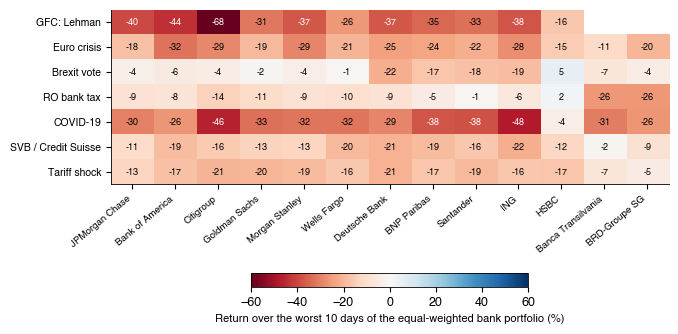

                          loss                start                  end  \
GFC: Lehman          37.605019  2008-11-10 00:00:00  2008-11-21 00:00:00   
Euro crisis          22.273518  2011-07-26 00:00:00  2011-08-10 00:00:00   
Brexit vote           7.940502  2016-06-22 00:00:00  2016-07-06 00:00:00   
RO bank tax          10.245407  2018-12-10 00:00:00  2018-12-21 00:00:00   
COVID-19             31.870647  2020-03-05 00:00:00  2020-03-18 00:00:00   
SVB / Credit Suisse  14.810164  2023-03-07 00:00:00  2023-03-20 00:00:00   
Tariff shock         15.996312  2025-03-25 00:00:00  2025-04-07 00:00:00   

                    n_banks  
GFC: Lehman              11  
Euro crisis              13  
Brexit vote              13  
RO bank tax              13  
COVID-19                 13  
SVB / Credit Suisse      13  
Tariff shock             13  


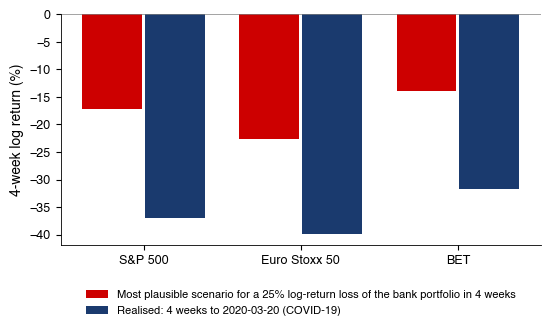

{'b': array([0.45317786, 0.65159282, 0.18021185]),
 'fstar': array([-17.16189976, -22.59486497, -13.8723129 ]),
 'd': np.float64(4.314402783533824),
 'p': np.float64(8.001746877289543e-06),
 'real': array([-37.0251002 , -39.95961109, -31.78650042]),
 'real_loss': np.float64(51.980238875235464)}

In [13]:
def stress_historical():
    """For each episode: the worst 10-day window of the equal-weighted bank portfolio."""
    Rl = joint_returns(INTL, start='2007-01-01')
    rows, port = {}, {}
    for name, a, b in EPISODES:
        keys = INTL + (RO if pd.Timestamp(a) >= pd.Timestamp('2010-01-01') else [])
        X = (Rl.loc[a:b] if keys == INTL else R.loc[a:b, keys])
        # exact log return of the daily-rebalanced portfolio: 100 ln(mean of gross simple returns)
        p = (100 * np.log(np.exp(X / 100).mean(axis=1))).rolling(10).sum()
        end = p.idxmin()
        i = X.index.get_loc(end)
        win = X.iloc[i - 9:i + 1]
        cum = 100 * (np.exp(win.sum() / 100) - 1)
        rows[name] = cum.reindex(ALL)
        port[name] = {'loss': -100 * (np.exp(p.min() / 100) - 1), 'start': win.index[0], 'end': win.index[-1],
                      'n_banks': len(keys)}
    return pd.DataFrame(rows).T, port


def fig_stress_hist(H):
    fig, ax = plt.subplots(figsize=(7.2, 3.6))
    im = ax.imshow(H.values, cmap='RdBu', vmin=-60, vmax=60, aspect='auto')
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            v = H.values[i, j]
            ax.text(j, i, '' if np.isnan(v) else f'{v:.0f}', ha='center', va='center', fontsize=6.5,
                    color='white' if abs(v) > 35 else 'black')
    ax.set_xticks(range(H.shape[1]))
    ax.set_xticklabels([NAMES[k] for k in H.columns], rotation=40, ha='right', fontsize=7)
    ax.set_yticks(range(H.shape[0]))
    ax.set_yticklabels(H.index, fontsize=7.5)
    cb = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.32)
    cb.set_label('Return over the worst 10 days of the equal-weighted bank portfolio (%)', fontsize=8)
    save_fig('ch18_stress_hist')


def weekly_returns(keys):
    p = prices(keys)
    w = p.resample('W-FRI').last().dropna()
    return 100 * np.log(w).diff().dropna()


def reverse_stress(target=25.0, weeks=4):
    """Reverse stress test: the most plausible factor scenario that produces a given loss.

    Model: weekly bank log returns (%) = beta' f + error, f = (S&P 500, Euro Stoxx 50, BET);
    over h weeks f ~ N(0, h Sigma) (no autocovariances). Portfolio loss (log return,
    factor-only approximation: idiosyncratic errors set to zero) L = -b'f, b = mean beta.
    Most likely scenario with L = target: f* = -target Sigma b / (b' Sigma b); Mahalanobis distance target / sqrt(b' Sigma b)."""
    W = weekly_returns(ALL + ['SPX', 'SX5E', 'BET'])
    F = W[['SPX', 'SX5E', 'BET']]
    Xf = np.column_stack([np.ones(len(F)), F.values])
    betas = {k: np.linalg.lstsq(Xf, W[k].values, rcond=None)[0][1:] for k in ALL}
    b = np.mean([betas[k] for k in ALL], axis=0)
    S = weeks * F.cov().values
    sb = np.sqrt(b @ S @ b)
    fstar = -target * S @ b / sb ** 2
    d = target / sb
    from scipy.stats import norm
    # realised factor moves in the worst 4 weeks of the portfolio (2020)
    port = W[ALL].mean(axis=1).rolling(weeks).sum()
    end = port.loc['2020'].idxmin()
    real = F.loc[:end].iloc[-weeks:].sum()
    return {'b': b, 'fstar': fstar, 'd': d, 'p': norm.cdf(-d), 'sigma_p': sb, 'target': target,
            'betas': {k: v for k, v in betas.items()}, 'real': real.values, 'real_loss': -port.loc[end],
            'real_end': end, 'real_model_loss': -b @ real.values, 'n_weeks': len(W)}


def fig_reverse(rv):
    fig, ax = plt.subplots(figsize=(6.2, 3.0))
    xs = np.arange(3)
    ax.bar(xs - 0.2, rv['fstar'], 0.38, color=IDAred,
           label=f'Most plausible scenario for a {rv["target"]:.0f}% log-return loss of the bank portfolio in 4 weeks')
    ax.bar(xs + 0.2, rv['real'], 0.38, color=MainBlue, label=f'Realised: 4 weeks to {rv["real_end"].date()} (COVID-19)')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xticks(xs)
    ax.set_xticklabels(['S&P 500', 'Euro Stoxx 50', 'BET'])
    ax.set_ylabel('4-week log return (%)')
    legend_outside_bottom(ax, ncol=1, y=-0.15)
    save_fig('ch18_reverse_stress')


H, port = stress_historical()
fig_stress_hist(H)
print(pd.DataFrame(port).T)
rv = reverse_stress()
fig_reverse(rv)
{k: rv[k] for k in ['b', 'fstar', 'd', 'p', 'real', 'real_loss']}

## 9. Inference for systemic-risk measures

- Joint block-bootstrap tests for ΔCoVaR, the Euler identity for MES, the Girardi–Ergün CoVaR and its backtest.
- LRMES by GJR-GARCH + DCC simulation and its model risk.
- Estimation error in the network: residual bootstrap, elastic-net VARs, Granger networks with multiple-testing control.
- Each cell below takes several minutes.

In [14]:
B = 999


def holm(p):
    """Holm correction (adjusted p-values) for a family of tests."""
    p = np.asarray(p, float)
    o = np.argsort(p)
    m = len(p)
    adj = np.maximum.accumulate((m - np.arange(m)) * p[o])
    out = np.empty(m)
    out[o] = np.minimum(adj, 1)
    return out


def bh(p, q=0.05):
    """Benjamini-Hochberg: rejection mask at false discovery rate q."""
    p = np.asarray(p, float)
    m = len(p)
    o = np.argsort(p)
    ok = p[o] <= q * np.arange(1, m + 1) / m
    k = np.max(np.nonzero(ok)[0]) + 1 if ok.any() else 0
    rej = np.zeros(m, bool)
    rej[o[:k]] = True
    return rej


def covar_tests(alpha=0.01, B=B, block=20, seed=SEED):
    """The same bootstrap draws for all banks -> joint distribution of Delta-CoVaR and of the slopes."""
    banks = US + EU
    sysr = {k: system_ex(k, US if k in US else EU).values for k in banks}
    x = {k: R[k].values for k in banks}
    n = len(R)
    point = {k: covar_static(sysr[k], x[k], alpha) for k in banks}
    b50 = {k: qreg(sysr[k], x[k], 0.5)[1] for k in banks}
    rng = np.random.default_rng(seed)
    D = np.zeros((B, len(banks)))
    DB = np.zeros((B, len(banks)))
    for r in range(B):
        idx = block_bootstrap_idx(n, block, rng)
        for j, k in enumerate(banks):
            c = covar_static(sysr[k][idx], x[k][idx], alpha)
            D[r, j] = c['dcovar']
            DB[r, j] = c['b'] - qreg(sysr[k][idx], x[k][idx], 0.5)[1]
    res = {'alpha': alpha, 'n': n, 'n_tail': n * alpha, 'banks': {}}
    for j, k in enumerate(banks):
        fit = QuantReg(sysr[k], sm.add_constant(x[k])).fit(q=alpha, max_iter=5000)     # kernel standard error (sandwich)
        dpt = point[k]['b'] - b50[k]
        se_db = DB[:, j].std(ddof=1)
        res['banks'][k] = {'dcovar': point[k]['dcovar'], 'b': point[k]['b'], 'b50': b50[k], 'se_b_kernel': fit.bse[1],
                           'se_b_boot': None, 'lo': np.percentile(D[:, j], 2.5), 'hi': np.percentile(D[:, j], 97.5),
                           'se_dcovar_boot': D[:, j].std(ddof=1), 'db': dpt, 'se_db': se_db,
                           'p_db': 2 * stats.norm.sf(abs(dpt) / se_db)}
    # equal contributions by pair, within each region: t = difference / bootstrap standard deviation of the difference
    pairs = []
    for mem in (US, EU):
        for a in range(len(mem)):
            for b_ in range(a + 1, len(mem)):
                i, j = banks.index(mem[a]), banks.index(mem[b_])
                d = point[mem[a]]['dcovar'] - point[mem[b_]]['dcovar']
                se = (D[:, i] - D[:, j]).std(ddof=1)
                pairs.append((mem[a], mem[b_], d, se, 2 * stats.norm.sf(abs(d) / se),
                              # overlap of the marginal intervals
                              not (res['banks'][mem[a]]['hi'] < res['banks'][mem[b_]]['lo'] or
                                   res['banks'][mem[b_]]['hi'] < res['banks'][mem[a]]['lo'])))
    p = np.array([q[4] for q in pairs])
    ph = holm(p)
    res['pairs'] = [{'a': q[0], 'b': q[1], 'd': q[2], 'se': q[3], 'p': q[4], 'p_holm': ph[i], 'overlap': q[5]}
                    for i, q in enumerate(pairs)]
    res['n_pairs'] = len(pairs)
    res['n_sig_raw'] = int((p < 0.05).sum())
    res['n_sig_holm'] = int((ph < 0.05).sum())
    res['n_sig_overlap'] = int(sum(1 for i, q in enumerate(pairs) if q[5] and p[i] < 0.05))
    res['n_db_sig'] = int(sum(v['p_db'] < 0.05 for v in res['banks'].values()))
    res['n_db_sig_holm'] = int((holm([v['p_db'] for v in res['banks'].values()]) < 0.05).sum())
    # joint Wald test: all Delta-CoVaR equal within a region (bootstrap covariance of the contrasts)
    for reg, mem in (('US', US), ('EU', EU)):
        ids = [banks.index(k) for k in mem]
        C = np.zeros((len(ids) - 1, len(banks)))
        for r_, i in enumerate(ids[1:]):
            C[r_, ids[0]], C[r_, i] = 1, -1
        dv = C @ np.array([point[k]['dcovar'] for k in banks])
        S = np.cov((D @ C.T).T)
        w = float(dv @ np.linalg.solve(S, dv))
        res[f'wald_{reg}'] = {'stat': w, 'df': len(ids) - 1, 'p': stats.chi2.sf(w, len(ids) - 1)}
    return res


def euler_check(alpha=0.05):
    X = R[US]
    port = X.mean(axis=1)
    q = np.quantile(port, alpha)
    es_p = -port[port <= q].mean()
    mes_p = {k: -X[k][port <= q].mean() for k in US}
    m = R['SPX']
    mes_m = {k: mes(X[k].values, m.values, alpha) for k in US}
    return {'es_port': es_p, 'sum_mes_port': np.mean(list(mes_p.values())), 'sum_mes_spx': np.mean(list(mes_m.values())),
            'mes_port': mes_p, 'mes_spx': mes_m, 'n_tail': int((port <= q).sum())}


def ge_covar(alpha=0.05):
    out = {}
    for k in US + EU:
        xs = system_ex(k, US if k in US else EU).values
        xi = R[k].values
        qa, qm = np.quantile(xi, alpha), np.quantile(xi, 0.5)
        dist = xs[xi <= qa]
        med = xs[np.abs(xi - xi.mean()) <= xi.std()]                       # benchmark state: a one-standard-deviation event
        out[k] = {'ge_covar': -np.quantile(dist, alpha), 'ge_covar_med': -np.quantile(med, alpha),
                  'ab_covar': covar_static(xs, xi, alpha)['covar'], 'n_cond': int(len(dist))}
        out[k]['ge_dcovar'] = out[k]['ge_covar'] - out[k]['ge_covar_med']
    return out


def kupiec(x, n, p):
    """Kupiec test (unconditional coverage): likelihood-ratio statistic LR ~ chi2(1) under H0: hit rate = p."""
    ph = x / n
    ll0 = x * np.log(p) + (n - x) * np.log(1 - p)
    ll1 = (x * np.log(ph) if x > 0 else 0) + ((n - x) * np.log(1 - ph) if x < n else 0)
    lr = -2 * (ll0 - ll1)
    return lr, stats.chi2.sf(lr, 1)


def backtest_ge(alpha=0.05, start=1000):
    """Out-of-sample backtest of the Girardi-Ergun CoVaR (historical, expanding window):
    joint hit 1{X_sys <= -CoVaR_t, X_i <= -VaR_i,t}, with probability alpha^2 under H0."""
    out = {}
    for k in US + EU:
        xs = system_ex(k, US if k in US else EU).values
        xi = R[k].values
        hits, vh = [], []
        for t in range(start, len(xi)):
            a, s = xi[:t], xs[:t]
            q = np.quantile(a, alpha)
            cov = -np.quantile(s[a <= q], alpha)
            vh.append(xi[t] <= q)
            hits.append((xi[t] <= q) and (xs[t] <= -cov))
        n, x = len(hits), int(np.sum(hits))
        lr, p = kupiec(x, n, alpha ** 2)
        lrv, pv = kupiec(int(np.sum(vh)), n, alpha)
        out[k] = {'n': n, 'hits': x, 'expected': n * alpha ** 2, 'lr': lr, 'p': p,
                  'var_hits': int(np.sum(vh)), 'var_p': pv}
    return out


ct = covar_tests(0.01)
print({k: ct[k] for k in ['n_pairs', 'n_sig_raw', 'n_sig_holm', 'wald_US', 'wald_EU']})
print(euler_check())
print(pd.DataFrame(ge_covar()).T.round(2))
pd.DataFrame(backtest_ge(0.05)).T.round(3)

{'n_pairs': 25, 'n_sig_raw': 4, 'n_sig_holm': 0, 'wald_US': {'stat': 14.158796228270754, 'df': 5, 'p': np.float64(0.014631571462532219)}, 'wald_EU': {'stat': 4.817416267300726, 'df': 4, 'p': np.float64(0.3065498909299027)}}
{'es_port': np.float64(4.3235104565334765), 'sum_mes_port': np.float64(4.3235104565334765), 'sum_mes_spx': np.float64(3.633062437196198), 'mes_port': {'JPM': np.float64(3.85140242697955), 'BAC': np.float64(4.70104460339196), 'C': np.float64(4.802273676361575), 'GS': np.float64(3.942391307488915), 'MS': np.float64(4.68667387249129), 'WFC': np.float64(3.9572768524875666)}, 'mes_spx': {'JPM': np.float64(3.2190251453478127), 'BAC': np.float64(3.8455630325750696), 'C': np.float64(4.029831041303956), 'GS': np.float64(3.3449003411152463), 'MS': np.float64(4.039487631827107), 'WFC': np.float64(3.3195674310079966)}, 'n_tail': 198}


      ge_covar  ge_covar_med  ab_covar  n_cond  ge_dcovar
JPM       7.70          1.60      3.81   198.0       6.10
BAC       7.88          1.60      3.67   198.0       6.28
C         7.45          1.63      3.58   198.0       5.82
GS        7.56          1.66      3.93   198.0       5.89
MS        7.31          1.60      3.72   198.0       5.71
WFC       7.95          1.79      3.89   198.0       6.15
DBK       8.04          1.84      4.10   198.0       6.20
BNP       7.86          1.82      3.95   198.0       6.04
SAN       8.07          1.83      3.98   198.0       6.24
INGA      7.67          1.92      3.83   198.0       5.75
HSBA      8.22          2.30      4.82   198.0       5.92


,n,hits,expected,lr,p,var_hits,var_p
JPM,2960.0,9.0,7.4,0.324,0.569,126.0,0.057
BAC,2960.0,8.0,7.4,0.048,0.827,105.0,0.000
C,2960.0,8.0,7.4,0.048,0.827,116.0,0.005
GS,2960.0,8.0,7.4,0.048,0.827,144.0,0.735
MS,2960.0,9.0,7.4,0.324,0.569,108.0,0.000
WFC,2960.0,8.0,7.4,0.048,0.827,169.0,0.083
DBK,2960.0,5.0,7.4,0.882,0.348,129.0,0.102
BNP,2960.0,9.0,7.4,0.324,0.569,97.0,0.000
SAN,2960.0,7.0,7.4,0.022,0.882,120.0,0.015
INGA,2960.0,9.0,7.4,0.324,0.569,86.0,0.000


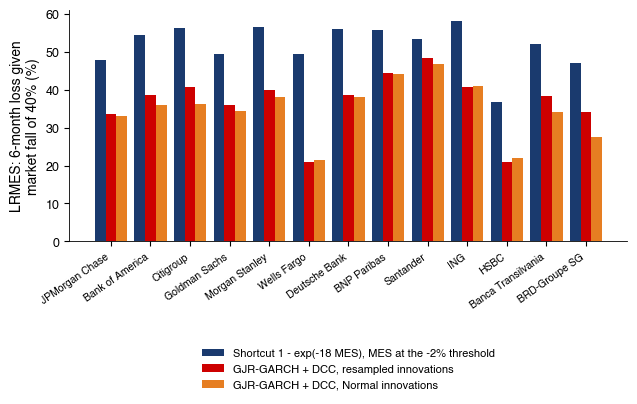

,short,v6,g6,be
JPM,47.8,33.5,33.0,10.6
BAC,54.6,38.6,36.0,14.3
C,56.1,40.8,36.3,13.0
GS,49.4,35.9,34.4,16.5
MS,56.4,40.0,38.0,16.3
WFC,49.4,20.8,21.5,6.7
DBK,55.9,38.7,38.2,14.4
BNP,55.8,44.5,44.1,15.6
SAN,53.3,48.2,46.7,16.6
INGA,58.0,40.8,41.1,12.5


In [15]:
def gjr_fit(r):
    """GJR-GARCH(1,1) with zero mean (log returns in %), quasi-maximum likelihood (QML)."""
    m = arch_model(r, mean='Zero', vol='GARCH', p=1, o=1, q=1, dist='normal', rescale=False).fit(disp='off')
    om, a, g, b = m.params[['omega', 'alpha[1]', 'gamma[1]', 'beta[1]']]
    s2 = m.conditional_volatility ** 2
    s2_next = om + (a + g * (r[-1] < 0)) * r[-1] ** 2 + b * s2[-1]
    return {'omega': om, 'alpha': a, 'gamma': g, 'beta': b, 'sig': np.sqrt(s2), 's2_next': s2_next}


def dcc_fit(e):
    """Bivariate DCC(1,1), second QML step (Engle, 2002); e = standardised residuals T x 2."""
    S = np.corrcoef(e.T)
    T = len(e)

    def filt(a, b):
        Q = S.copy()
        rho = np.empty(T)
        for t in range(T):
            rho[t] = Q[0, 1] / np.sqrt(Q[0, 0] * Q[1, 1])
            Q = (1 - a - b) * S + a * np.outer(e[t], e[t]) + b * Q
        return rho, Q

    def nll(th):
        a, b = th
        if a <= 0 or b <= 0 or a + b >= 0.999:
            return 1e10
        rho, _ = filt(a, b)
        z1, z2 = e[:, 0], e[:, 1]
        return 0.5 * np.sum(np.log(1 - rho ** 2) + (z1 ** 2 + z2 ** 2 - 2 * rho * z1 * z2) / (1 - rho ** 2)
                            - (z1 ** 2 + z2 ** 2))

    best = min((optimize.minimize(nll, x0, method='Nelder-Mead', options={'xatol': 1e-5, 'fatol': 1e-4})
                for x0 in [(0.02, 0.95), (0.05, 0.90)]), key=lambda o: o.fun)
    a, b = best.x
    rho, Q = filt(a, b)
    return {'a': a, 'b': b, 'S': S, 'rho': rho, 'Q_next': Q}


def simulate_market(gm, eps_m, idx):
    """Market paths (GJR) from the resampled innovations eps_m[idx], idx: S x h."""
    Sn, h = idx.shape
    s2 = np.full(Sn, gm['s2_next'])
    cum = np.zeros(Sn)
    for t in range(h):
        r = np.sqrt(s2) * eps_m[idx[:, t]]
        cum += r
        s2 = gm['omega'] + (gm['alpha'] + gm['gamma'] * (r < 0)) * r ** 2 + gm['beta'] * s2
    return cum


def simulate_firm(gf, gm, dcc, eps_m, xi, idx):
    """Bank paths conditional on the same drawn dates (Appendix A of Brownlees & Engle, 2017)."""
    Sn, h = idx.shape
    s2i = np.full(Sn, gf['s2_next'])
    q11 = np.full(Sn, dcc['Q_next'][0, 0])
    q22 = np.full(Sn, dcc['Q_next'][1, 1])
    q12 = np.full(Sn, dcc['Q_next'][0, 1])
    cum = np.zeros(Sn)
    a, b, S = dcc['a'], dcc['b'], dcc['S']
    for t in range(h):
        rho = q12 / np.sqrt(q11 * q22)
        em = eps_m[idx[:, t]]
        ei = rho * em + np.sqrt(1 - rho ** 2) * xi[idx[:, t]]
        r = np.sqrt(s2i) * ei
        cum += r
        s2i = gf['omega'] + (gf['alpha'] + gf['gamma'] * (r < 0)) * r ** 2 + gf['beta'] * s2i
        q11 = (1 - a - b) * S[0, 0] + a * ei ** 2 + b * q11
        q22 = (1 - a - b) * S[1, 1] + a * em ** 2 + b * q22
        q12 = (1 - a - b) * S[0, 1] + a * ei * em + b * q12
    return cum


def _sim_gauss_market(gm, eps):
    Sn, h = eps.shape
    s2 = np.full(Sn, gm['s2_next'])
    cum = np.zeros(Sn)
    for t in range(h):
        r = np.sqrt(s2) * eps[:, t]
        cum += r
        s2 = gm['omega'] + (gm['alpha'] + gm['gamma'] * (r < 0)) * r ** 2 + gm['beta'] * s2
    return cum


def _sim_gauss_firm(gf, gm, dcc, eps_m_paths, rng):
    """Variant with Normal innovations (the same crisis paths of the market, xi ~ N(0,1))."""
    Sn, h = eps_m_paths.shape
    xi = rng.standard_normal((Sn, h))
    s2i = np.full(Sn, gf['s2_next'])
    q11, q22, q12 = (np.full(Sn, dcc['Q_next'][i, j]) for i, j in [(0, 0), (1, 1), (0, 1)])
    a, b, S = dcc['a'], dcc['b'], dcc['S']
    cum = np.zeros(Sn)
    for t in range(h):
        rho = q12 / np.sqrt(q11 * q22)
        em = eps_m_paths[:, t]
        ei = rho * em + np.sqrt(1 - rho ** 2) * xi[:, t]
        r = np.sqrt(s2i) * ei
        cum += r
        s2i = gf['omega'] + (gf['alpha'] + gf['gamma'] * (r < 0)) * r ** 2 + gf['beta'] * s2i
        q11 = (1 - a - b) * S[0, 0] + a * ei ** 2 + b * q11
        q22 = (1 - a - b) * S[1, 1] + a * em ** 2 + b * q22
        q12 = (1 - a - b) * S[0, 1] + a * ei * em + b * q12
    return cum


def lrmes_sim(end, h, C, Sn, seed=SEED, gaussian=False):
    """LRMES (fraction) for the 13 banks at date `end`, horizon h days, threshold C (arithmetic market return)."""
    rng = np.random.default_rng(seed)
    Rs = R.loc[:end]
    out, info = {}, {}
    for reg, mem in (('US', US), ('EU', EU), ('RO', RO)):
        rm = Rs[REGION_INDEX[reg]].values
        gm = gjr_fit(rm)
        eps_m = rm / gm['sig']
        T = len(rm)
        # 1) market paths; only the crisis scenarios are kept (algorithm of Appendix A of Brownlees & Engle, 2017)
        keep_idx, n_all = [], 0
        for _ in range(Sn // 20000):
            idx = rng.integers(0, T, size=(20000, h))
            n_all += 20000
            if gaussian:
                eps_draw = rng.standard_normal((20000, h))
                # Gaussian paths: indices into their own matrix of innovations
                cm = _sim_gauss_market(gm, eps_draw)
                keep_idx.append(eps_draw[np.exp(cm / 100) - 1 < C])
            else:
                cm = simulate_market(gm, eps_m, idx)
                keep_idx.append(idx[np.exp(cm / 100) - 1 < C])
        kept = np.concatenate(keep_idx)
        info[reg] = {'p_crisis': len(kept) / n_all, 'n_crisis': len(kept), 'market': gm}
        for k in mem:
            ri = Rs[k].values
            gf = gjr_fit(ri)
            e = np.column_stack([ri / gf['sig'], eps_m])
            dcc = dcc_fit(e)
            xi = (e[:, 0] - dcc['rho'] * e[:, 1]) / np.sqrt(1 - dcc['rho'] ** 2)
            if gaussian:
                ci = _sim_gauss_firm(gf, gm, dcc, kept, rng)
            else:
                ci = simulate_firm(gf, gm, dcc, eps_m, xi, kept)
            Ri = np.exp(ci / 100) - 1
            out[k] = {'lrmes': -Ri.mean(), 'mc_se': Ri.std(ddof=1) / np.sqrt(len(Ri)),
                      'q05': -np.quantile(Ri, 0.95), 'q95': -np.quantile(Ri, 0.05),
                      'rho_last': dcc['rho'][-1], 'dcc_a': dcc['a'], 'dcc_b': dcc['b'],
                      'gjr': [gf['alpha'], gf['gamma'], gf['beta']]}
    return out, info


def srisk_simulation():
    end = R.index[-1]
    be, be_info = lrmes_sim(end, 22, -0.10, 200000, SEED)                 # Brownlees & Engle (2017): h = 22, C = -10%
    v6, v6_info = lrmes_sim(end, 126, -0.40, 400000, SEED + 1)            # the 6-month / -40% scenario
    g6, _ = lrmes_sim(end, 126, -0.40, 400000, SEED + 2, gaussian=True)   # the same, with Normal innovations
    cv, cv_info = lrmes_sim(pd.Timestamp('2020-03-31'), 22, -0.10, 200000, SEED + 3)   # conditional on 31.03.2020
    short = {k: lrmes(mes_threshold(R[k].values, R[REGION_INDEX[region_of(k)]].values, -2.0)) for k in ALL}
    res = {'end': end, 'be': be, 'v6': v6, 'g6': g6, 'covid': cv, 'short': short,
           'p_crisis_be': {r: be_info[r]['p_crisis'] for r in be_info},
           'p_crisis_v6': {r: v6_info[r]['p_crisis'] for r in v6_info},
           'n_crisis_v6': {r: v6_info[r]['n_crisis'] for r in v6_info},
           'p_crisis_covid': {r: cv_info[r]['p_crisis'] for r in cv_info}}
    s = pd.DataFrame({'short': short, 'v6': {k: v['lrmes'] for k, v in v6.items()},
                      'g6': {k: v['lrmes'] for k, v in g6.items()}, 'be': {k: v['lrmes'] for k, v in be.items()}})
    res['spearman_short_v6'] = stats.spearmanr(s['short'], s['v6']).correlation
    res['spearman_v6_g6'] = stats.spearmanr(s['v6'], s['g6']).correlation
    res['ratio_range'] = [float((s['v6'] / s['short']).min()), float((s['v6'] / s['short']).max())]
    res['Lstar_v6'] = {k: breakeven_leverage(v['lrmes']) for k, v in v6.items()}
    res['Lstar_be'] = {k: breakeven_leverage(v['lrmes']) for k, v in be.items()}
    return res, s


def fig_lrmes_models(s):
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    xs = np.arange(len(ALL))
    w = 0.27
    ax.bar(xs - w, 100 * s.loc[ALL, 'short'], w, color=MainBlue, label='Shortcut 1 - exp(-18 MES), MES at the -2% threshold')
    ax.bar(xs, 100 * s.loc[ALL, 'v6'], w, color=IDAred, label='GJR-GARCH + DCC, resampled innovations')
    ax.bar(xs + w, 100 * s.loc[ALL, 'g6'], w, color=Orange, label='GJR-GARCH + DCC, Normal innovations')
    ax.set_xticks(xs)
    ax.set_xticklabels([NAMES[k] for k in ALL], rotation=35, ha='right', fontsize=7.5)
    ax.set_ylabel('LRMES: 6-month loss given\nmarket fall of 40% (%)')
    legend_outside_bottom(ax, ncol=1, y=-0.42)
    save_fig('ch18_lrmes_models')


sr, s = srisk_simulation()
fig_lrmes_models(s)
(100 * s).round(1)

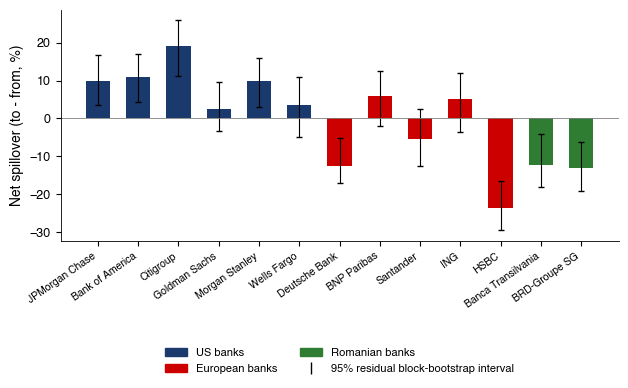

total 63.9 [59.9 65.8]


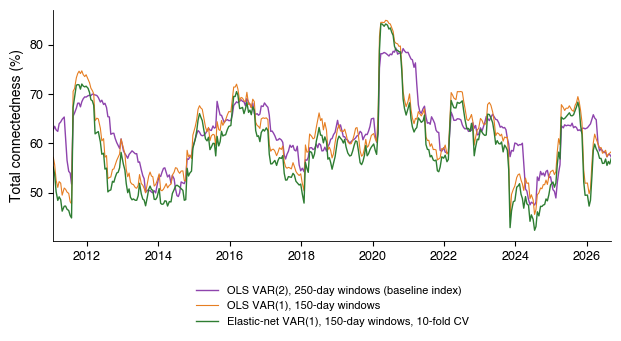

       ols250_p2  ols250_p1  ols150  enet150    bic
count      372.0      372.0   372.0    372.0  372.0
mean        62.0       61.7    61.1     58.7    1.0
std          6.7        7.6     7.9      8.3    0.0
min         47.5       45.7    45.1     42.4    1.0
25%         58.2       57.5    54.6     52.0    1.0
50%         62.4       61.6    60.7     58.2    1.0
75%         65.4       65.8    65.8     63.4    1.0
max         79.3       82.5    84.9     84.2    1.0


{'ret': {'m': 156,
  'raw': 57,
  'bonf': 33,
  'holm': 33,
  'bh': 55,
  'expected_false_raw': 7.800000000000001},
 'vol': {'m': 156,
  'raw': 153,
  'bonf': 140,
  'holm': 150,
  'bh': 153,
  'expected_false_raw': 7.800000000000001}}

In [16]:
def var_simulate(A, c, E, Y0, idx):
    p = len(A)
    T = len(idx)
    k = A[0].shape[0]
    Y = np.zeros((T + p, k))
    Y[:p] = Y0
    for t in range(p, T + p):
        Y[t] = c + sum(A[l] @ Y[t - l - 1] for l in range(p)) + E[idx[t - p]]
    return Y


def var_fit_c(Y, p):
    Y = np.asarray(Y, float)
    T, k = Y.shape
    X = np.hstack([np.ones((T - p, 1))] + [Y[p - l - 1:T - l - 1] for l in range(p)])
    Bc = np.linalg.lstsq(X, Y[p:], rcond=None)[0]
    E = Y[p:] - X @ Bc
    return [Bc[1 + l * k:1 + (l + 1) * k].T for l in range(p)], Bc[0], E


def spill_bootstrap(Y, p, H=10, B=B, block=20, seed=SEED):
    """Percentile interval for total and net connectedness (residual block bootstrap, VAR re-estimated)."""
    Y = np.asarray(Y, float)
    A, c, E = var_fit_c(Y, p)
    rng = np.random.default_rng(seed)
    tot, net = [], []
    for _ in range(B):
        idx = block_bootstrap_idx(len(E), block, rng)
        Yb = var_simulate(A, c, E, Y[:p], idx)
        Ab, Sb = var_fit(Yb, p)
        st = spillover_table(gfevd(Ab, Sb, H), list(range(Y.shape[1])))
        tot.append(st['total'])
        net.append(st['net'].values)
    return np.array(tot), np.array(net)


def fig_spill_ci(point_net, net_draws):
    lo, hi = np.percentile(net_draws, [2.5, 97.5], axis=0)
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    xs = np.arange(len(ALL))
    ax.bar(xs, point_net, color=[REGION_COL[region_of(k)] for k in ALL], width=0.6)
    ax.errorbar(xs, point_net, yerr=[point_net - lo, hi - point_net], fmt='none', ecolor='black', capsize=2, lw=0.8)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks(xs)
    ax.set_xticklabels([NAMES[k] for k in ALL], rotation=35, ha='right', fontsize=7.5)
    ax.set_ylabel('Net spillover (to - from, %)')
    h = [plt.Rectangle((0, 0), 1, 1, color=REGION_COL[r]) for r in ['US', 'EU', 'RO']] + \
        [plt.Line2D([], [], color='black', marker='|', ls='', ms=8)]
    ax.legend(h, ['US banks', 'European banks', 'Romanian banks', '95% residual block-bootstrap interval'],
              loc='upper center', bbox_to_anchor=(0.5, -0.42), ncol=2, frameon=False)
    save_fig('ch18_spill_ci')
    return lo, hi


def aenet_eq(X, y, w, lambdas, folds=10, seed=SEED):
    """min sum (y - Xb)^2 + lam sum w_i (|b_i|/2 + b_i^2/2)  (equation (9)); lambda by 10-fold cross-validation."""
    def fit(X, y, lam):
        Xc, yc = X - X.mean(0), y - y.mean()
        z = (Xc ** 2).sum(0)
        b = np.zeros(X.shape[1])
        r = yc.copy()
        for _ in range(200):
            b_old = b.copy()
            for j in range(len(b)):
                r += Xc[:, j] * b[j]
                rho = Xc[:, j] @ r
                b[j] = np.sign(rho) * max(abs(rho) - lam * w[j] / 4, 0) / (z[j] + lam * w[j] / 2)
                r -= Xc[:, j] * b[j]
            if np.max(np.abs(b - b_old)) < 1e-7:
                break
        return y.mean() - X.mean(0) @ b, b
    rng = np.random.default_rng(seed)
    fid = rng.permutation(len(y)) % folds
    cv = []
    for lam in lambdas:
        err = 0
        for f in range(folds):
            tr, te = fid != f, fid == f
            c0, b = fit(X[tr], y[tr], lam)
            err += ((y[te] - c0 - X[te] @ b) ** 2).sum()
        cv.append(err)
    lam = lambdas[int(np.argmin(cv))]
    return fit(X, y, lam), lam


def var_aenet(Y, p, lambdas=None):
    """VAR(p) with adaptive elastic net, equation by equation; weights w = 1/|b_OLS|."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    X = np.hstack([Y[p - l - 1:T - l - 1] for l in range(p)])
    Yt = Y[p:]
    lambdas = np.logspace(0, 5, 26) if lambdas is None else lambdas
    Bm = np.zeros((k * p, k))
    c = np.zeros(k)
    nz, lam_sel = 0, []
    for i in range(k):
        bols = np.linalg.lstsq(np.column_stack([np.ones(len(X)), X]), Yt[:, i], rcond=None)[0][1:]
        (c[i], Bm[:, i]), lam = aenet_eq(X, Yt[:, i], 1 / np.abs(bols), lambdas)
        nz += int((np.abs(Bm[:, i]) > 1e-10).sum())
        lam_sel.append(lam)
    E = Yt - c - X @ Bm
    S = E.T @ E / (len(Yt) - 1)
    A = [Bm[l * k:(l + 1) * k].T for l in range(p)]
    return A, S, nz / (k * k * p)


def var_enet_window(Y, p):
    """Elastic net (w_i = 1) for the rolling windows; the L1:L2 = 1:1 penalty of equation (9) <=> l1_ratio = 1/3."""
    T, k = Y.shape
    X = np.hstack([Y[p - l - 1:T - l - 1] for l in range(p)])
    Yt = Y[p:]
    Bm = np.zeros((k * p, k))
    c = np.zeros(k)
    for i in range(k):
        m = ElasticNetCV(l1_ratio=1 / 3, cv=10, n_alphas=30, max_iter=5000).fit(X, Yt[:, i])
        Bm[:, i], c[i] = m.coef_, m.intercept_
    E = Yt - c - X @ Bm
    S = E.T @ E / (len(Yt) - 1)
    return [Bm[l * k:(l + 1) * k].T for l in range(p)], S


def rolling_compare(Y, step=10, H=10):
    """Total connectedness: OLS VAR(2) on 250 days (baseline index) against elastic net and OLS on 150 days."""
    Y = pd.DataFrame(Y)
    rows = {}
    for end in range(250, len(Y) + 1, step):
        d = Y.index[end - 1]
        w250 = Y.iloc[end - 250:end].values
        w150 = Y.iloc[end - 150:end].values
        A, S = var_fit(w250, 2)
        c250 = spillover_table(gfevd(A, S, H), list(Y.columns))['total']
        A, S = var_fit(w150, 1)
        c150 = spillover_table(gfevd(A, S, H), list(Y.columns))['total']
        A, S = var_enet_window(w150, 1)
        ce = spillover_table(gfevd(A, S, H), list(Y.columns))['total']
        A1, S1 = var_fit(w250, 1)
        c250p1 = spillover_table(gfevd(A1, S1, H), list(Y.columns))['total']
        rows[d] = {'ols250_p2': c250, 'ols250_p1': c250p1, 'ols150': c150, 'enet150': ce,
                   'bic': var_bic(w250, 3)}
    return pd.DataFrame(rows).T


def fig_spill_enet(rc):
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    ax.plot(rc.index, rc['ols250_p2'], color=Purple, lw=1.0, label='OLS VAR(2), 250-day windows (baseline index)')
    ax.plot(rc.index, rc['ols150'], color=Orange, lw=0.8, label='OLS VAR(1), 150-day windows')
    ax.plot(rc.index, rc['enet150'], color=Forest, lw=1.0, label='Elastic-net VAR(1), 150-day windows, 10-fold CV')
    ax.set_ylabel('Total connectedness (%)')
    ax.set_xlim(rc.index[0], rc.index[-1])
    legend_outside_bottom(ax, ncol=1, y=-0.15)
    save_fig('ch18_spill_enet')


def granger_pairs(Y, p=1, extra=0):
    """Robust (HC0) Wald test for j -> i: regression of y_i on p (+extra) lags of y_i and y_j;
    extra = 1 gives the lag-augmented test (Toda-Yamamoto), valid also for highly persistent series."""
    Y = pd.DataFrame(Y)
    L = p + extra
    out = []
    for i in Y.columns:
        for j in Y.columns:
            if i == j:
                continue
            d = pd.concat({f'{v}{l}': Y[v].shift(l) for v in (i, j) for l in range(1, L + 1)}, axis=1)
            d['y'] = Y[i]
            d = d.dropna()
            X = sm.add_constant(d.drop(columns='y'))
            f = sm.OLS(d['y'], X).fit(cov_type='HC0')
            names = [f'{j}{l}' for l in range(1, p + 1)]
            w = f.wald_test(' , '.join(f'{nm} = 0' for nm in names), scalar=True)
            out.append((j, i, float(w.pvalue)))
    return out


def granger_fdr():
    res = {}
    for lab, Y, p, ex in [('ret', R[ALL], 1, 0), ('vol', V, 1, 1)]:
        g = granger_pairs(Y, p, ex)
        pv = np.array([x[2] for x in g])
        res[lab] = {'m': len(pv), 'raw': int((pv < 0.05).sum()), 'bonf': int((pv < 0.05 / len(pv)).sum()),
                    'holm': int((holm(pv) < 0.05).sum()), 'bh': int(bh(pv, 0.05).sum()),
                    'expected_false_raw': 0.05 * len(pv)}
    return res


p = var_bic(V.values, 5)
tot_b, net_b = spill_bootstrap(V.values, p)
st = spillover_table(gfevd(*var_fit(V.values, p), 10), ALL)
fig_spill_ci(st['net'].values, net_b)
print('total', round(st['total'], 1), np.percentile(tot_b, [2.5, 97.5]).round(1))
rc = rolling_compare(V, step=10)
fig_spill_enet(rc)
print(rc.describe().round(1))
granger_fdr()

## Summary

- Exposure (MES, SRISK), contribution (ΔCoVaR) and connectedness (spillover and tail networks) answer different questions.
- Rankings of banks are uncertain: test differences on joint bootstrap draws and correct for multiple tests.